# Notebook 03: Demand Prediction Agent

Predicts next-slot charging demand and congestion probability for each station/grid.

**Outputs → `outputs/`:**
- `demand_predictions.csv`: per-slot predicted utilisation, load, congestion probability
- `demand_metrics.csv`: RMSE / MAE / R² for model vs naïve baseline

**Agent design:**
- Primary model: `HistGradientBoostingRegressor/Classifier` (sklearn) — handles NaN natively, no native wheels required
- Baseline: seasonal-naïve (mean of same hour × day-of-week)
- Strict time-based train/test split (no data leakage)
- Separate models for ACN and UrbanEV panels

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from agents import DemandPredictionAgent, select_features_urbanev, select_features_acn
from features import BASELINE_TARIFF

OUT_DATA = Path('..') / 'data_processed'
OUTPUTS  = Path('..') / 'outputs'
OUT_FIG  = OUTPUTS / 'figures'
OUTPUTS.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Ready')

Ready


## 1. UrbanEV — Train/Test Split and Feature Matrix

In [2]:
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

# Strict time split: last 20% of timestamps = test
ts_sorted = sorted(uev['timestamp'].unique())
split_idx = int(len(ts_sorted) * 0.8)
ts_train = set(ts_sorted[:split_idx])
ts_test  = set(ts_sorted[split_idx:])

uev_train = uev[uev['timestamp'].isin(ts_train)].copy()
uev_test  = uev[uev['timestamp'].isin(ts_test)].copy()
print(f'Train rows: {len(uev_train):,}  ({uev_train["datetime"].min()} → {uev_train["datetime"].max()})')
print(f'Test rows : {len(uev_test):,}  ({uev_test["datetime"].min()} → {uev_test["datetime"].max()})')

Train rows: 1,707,264  (2022-06-19 00:00:00 → 2022-07-12 23:55:00)
Test rows : 426,816  (2022-07-13 00:00:00 → 2022-07-18 23:55:00)


In [3]:
feat_cols = select_features_urbanev(uev)
print(f'Feature columns ({len(feat_cols)}): {feat_cols}')

# Drop rows where targets are NaN
uev_tr = uev_train.dropna(subset=['utilization_rate','volume','congested'])
uev_te = uev_test.dropna(subset=['utilization_rate','volume','congested'])

X_tr = uev_tr[feat_cols]
X_te = uev_te[feat_cols]
y_util_tr, y_util_te = uev_tr['utilization_rate'], uev_te['utilization_rate']
y_load_tr, y_load_te = uev_tr['volume'], uev_te['volume']
y_cong_tr, y_cong_te = uev_tr['congested'], uev_te['congested']

print(f'X_train: {X_tr.shape}, X_test: {X_te.shape}')
print(f'Congestion base rate (train): {y_cong_tr.mean():.2%}')

Feature columns (23): ['hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'count', 'fast_count', 'slow_count', 'area', 'CBD', 'lag_1_occupancy', 'lag_12_occupancy', 'lag_288_occupancy', 'lag_1_volume', 'lag_12_volume', 'lag_1_utilization_rate', 'lag_12_utilization_rate', 'lag_288_utilization_rate', 'roll_2h_occupancy', 'roll_2h_volume', 'roll_2h_utilization_rate', 'lag_1_price', 'roll_2h_price']
X_train: (1707264, 23), X_test: (426816, 23)
Congestion base rate (train): 1.02%


## 2. UrbanEV — Fit Demand Agent

In [4]:
uev_agent = DemandPredictionAgent()
uev_agent.fit(X_tr, y_util_tr, y_load_tr, y_cong_tr)
print('UrbanEV agent fitted.')

UrbanEV agent fitted.


In [5]:
# Predict on test set
uev_preds = uev_agent.predict(X_te)

# Naïve baseline: mean of same hour+dow in train
uev_te_aug = uev_te.copy()
naive_util = DemandPredictionAgent.naive_baseline(uev_tr, 'utilization_rate')
naive_load = DemandPredictionAgent.naive_baseline(uev_tr, 'volume')

# Evaluate
uev_metrics = []
uev_metrics.append(uev_agent.evaluate(y_util_te, uev_preds['pred_utilization'], 'HGB Utilization'))
uev_metrics.append(uev_agent.evaluate(y_load_te, uev_preds['pred_load'], 'HGB Load'))
uev_metrics.append(uev_agent.evaluate(y_util_te,
    DemandPredictionAgent.naive_baseline(uev_tr.assign(hour=uev_tr['hour'], dow=uev_tr['dow']), 'utilization_rate')[:len(y_util_te)] if False else
    uev_te[['hour','dow']].merge(uev_tr.groupby(['hour','dow'])['utilization_rate'].mean().reset_index(), on=['hour','dow'], how='left')['utilization_rate'].values,
    'Naive Baseline Utilization'))
uev_metrics.append(uev_agent.evaluate(y_load_te,
    uev_te[['hour','dow']].merge(uev_tr.groupby(['hour','dow'])['volume'].mean().reset_index(), on=['hour','dow'], how='left')['volume'].values,
    'Naive Baseline Load'))

uev_metrics_df = pd.DataFrame(uev_metrics)
print('=== UrbanEV Model Metrics ===')
print(uev_metrics_df.to_string(index=False))

=== UrbanEV Model Metrics ===
                     label       RMSE       MAE       R2
           HGB Utilization   0.014677  0.005623 0.993113
                  HGB Load   6.866034  1.799261 0.995919
Naive Baseline Utilization   0.172386  0.134027 0.049813
       Naive Baseline Load 106.985067 48.919147 0.009245


## 3. ACN — Train/Test and Fit

In [6]:
acn_h = pd.read_parquet(OUT_DATA / 'acn_station_hour.parquet')
acn_h['slot'] = pd.to_datetime(acn_h['slot'], utc=True)

# Time split
slots_sorted = sorted(acn_h['slot'].unique())
split_slot = slots_sorted[int(len(slots_sorted)*0.8)]
acn_train = acn_h[acn_h['slot'] < split_slot].copy()
acn_test  = acn_h[acn_h['slot'] >= split_slot].copy()
print(f'ACN Train: {len(acn_train):,} rows | Test: {len(acn_test):,} rows')

feat_acn = select_features_acn(acn_h)
print(f'ACN features: {feat_acn}')

acn_tr_clean = acn_train.dropna(subset=['utilization_rate','sessions'])
acn_te_clean = acn_test.dropna(subset=['utilization_rate','sessions'])

acn_tr_clean = acn_tr_clean.copy()
acn_te_clean = acn_te_clean.copy()
acn_tr_clean['congested'] = (acn_tr_clean['utilization_rate'] > 0.8).astype(int)
acn_te_clean['congested'] = (acn_te_clean['utilization_rate'] > 0.8).astype(int)

acn_agent = DemandPredictionAgent(target_load='sessions')
acn_agent.fit(
    acn_tr_clean[feat_acn],
    acn_tr_clean['utilization_rate'],
    acn_tr_clean['sessions'],
    acn_tr_clean['congested'],
)
acn_preds = acn_agent.predict(acn_te_clean[feat_acn])

acn_metrics = []
acn_metrics.append(acn_agent.evaluate(acn_te_clean['utilization_rate'], acn_preds['pred_utilization'], 'HGB Utilization (ACN)'))
acn_metrics.append(acn_agent.evaluate(acn_te_clean['sessions'], acn_preds['pred_load'], 'HGB Sessions (ACN)'))
naive_u = acn_te_clean[['hour','dow']].merge(acn_tr_clean.groupby(['hour','dow'])['utilization_rate'].mean().reset_index(),on=['hour','dow'],how='left')['utilization_rate'].values
acn_metrics.append(acn_agent.evaluate(acn_te_clean['utilization_rate'], naive_u, 'Naive Baseline (ACN)'))

acn_metrics_df = pd.DataFrame(acn_metrics)
print('=== ACN Model Metrics ===')
print(acn_metrics_df.to_string(index=False))

ACN Train: 12,140 rows | Test: 2,699 rows
ACN features: ['hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'lag_1h_sessions', 'lag_24h_sessions', 'rolling_7d_sessions']


=== ACN Model Metrics ===
                label     RMSE      MAE        R2
HGB Utilization (ACN) 0.176502 0.105991  0.061883
   HGB Sessions (ACN) 0.093112 0.013813 -0.021396
 Naive Baseline (ACN) 0.176819 0.105086  0.058503


## 4. Visualise Predictions

<>:34: SyntaxWarning: invalid escape sequence '\('
<>:34: SyntaxWarning: invalid escape sequence '\('
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31260/2857195968.py:34: SyntaxWarning: invalid escape sequence '\('
  axes[1,1].set_xticklabels(hgb['label'].str.replace(' \(ACN\)','',regex=True), rotation=20, ha='right', fontsize=9)


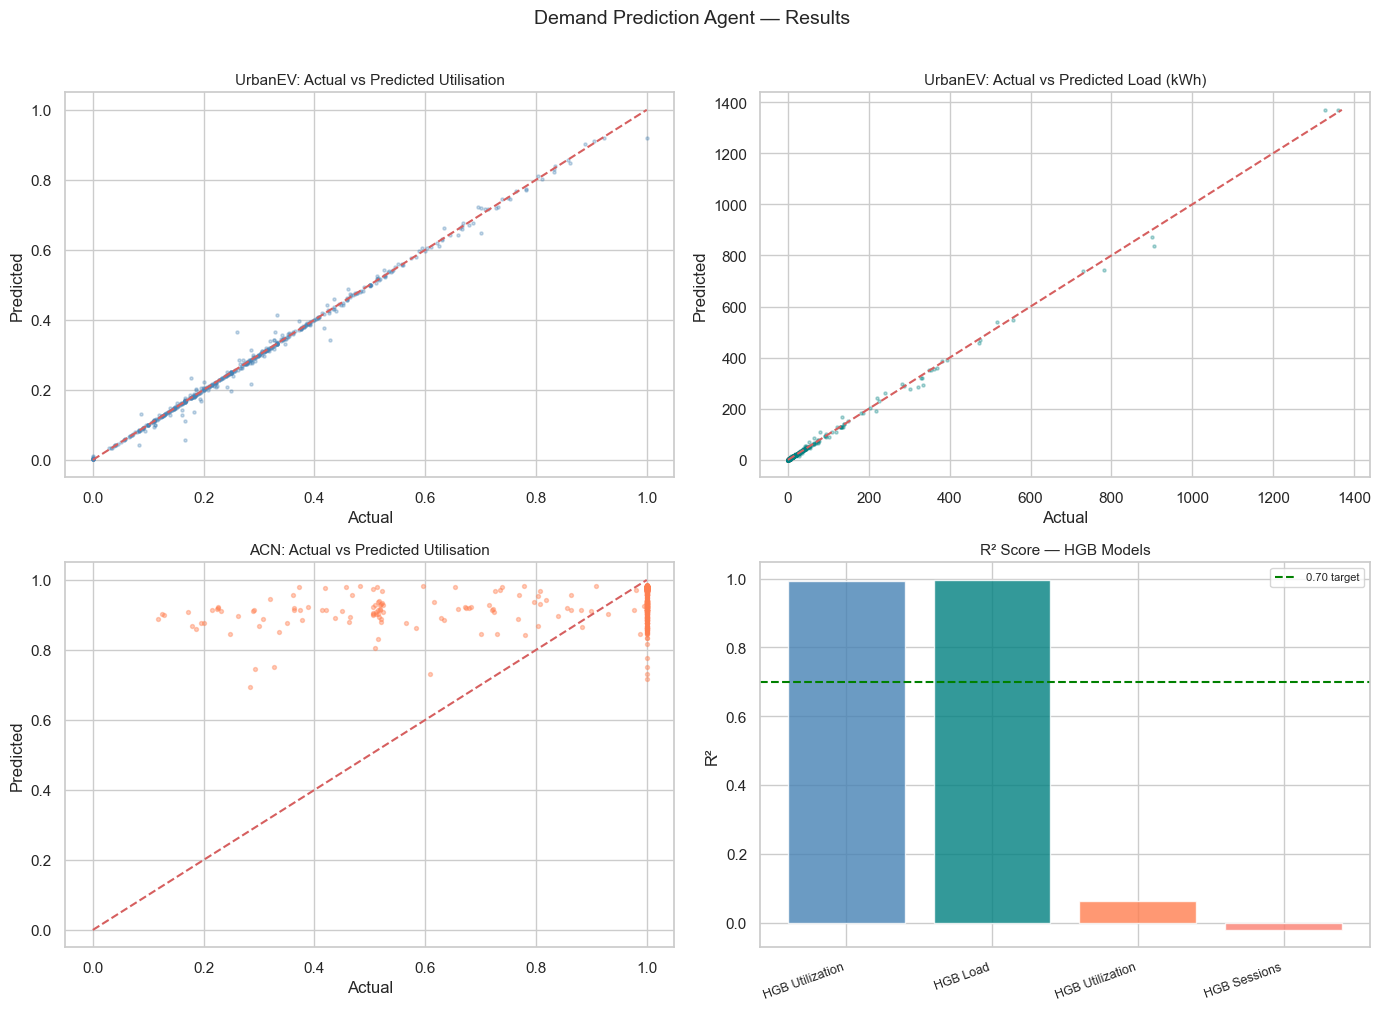

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# UrbanEV utilisation: actual vs predicted (sample)
n = min(500, len(uev_preds))
idx = np.linspace(0, len(uev_preds)-1, n).astype(int)
axes[0,0].scatter(y_util_te.values[idx], uev_preds['pred_utilization'].values[idx],
                  alpha=0.3, s=5, color='steelblue')
axes[0,0].plot([0,1],[0,1], 'r--', lw=1.5)
axes[0,0].set_title('UrbanEV: Actual vs Predicted Utilisation', fontsize=11)
axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')

# UrbanEV load
axes[0,1].scatter(y_load_te.values[idx], uev_preds['pred_load'].values[idx],
                  alpha=0.3, s=5, color='teal')
mx = max(y_load_te.values[idx].max(), uev_preds['pred_load'].values[idx].max())
axes[0,1].plot([0,mx],[0,mx], 'r--', lw=1.5)
axes[0,1].set_title('UrbanEV: Actual vs Predicted Load (kWh)', fontsize=11)
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')

# ACN utilisation
n2 = min(500, len(acn_preds))
axes[1,0].scatter(acn_te_clean['utilization_rate'].values[:n2], acn_preds['pred_utilization'].values[:n2],
                  alpha=0.4, s=8, color='coral')
axes[1,0].plot([0,1],[0,1], 'r--', lw=1.5)
axes[1,0].set_title('ACN: Actual vs Predicted Utilisation', fontsize=11)
axes[1,0].set_xlabel('Actual'); axes[1,0].set_ylabel('Predicted')

# Metrics bar chart
all_metrics = pd.concat([uev_metrics_df, acn_metrics_df])
hgb = all_metrics[all_metrics['label'].str.startswith('HGB')]
x = np.arange(len(hgb))
axes[1,1].bar(x, hgb['R2'], color=['steelblue','teal','coral','salmon'][:len(hgb)], alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(hgb['label'].str.replace(' \(ACN\)','',regex=True), rotation=20, ha='right', fontsize=9)
axes[1,1].set_title('R² Score — HGB Models', fontsize=11)
axes[1,1].set_ylabel('R²')
axes[1,1].axhline(0.7, color='green', linestyle='--', lw=1.5, label='0.70 target')
axes[1,1].legend(fontsize=8)

plt.suptitle('Demand Prediction Agent — Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_FIG / 'demand_agent_results.png', dpi=150)
plt.show()

## 5. Export Outputs

In [8]:
# Demand predictions CSV (UrbanEV test set)
uev_out = uev_te[['timestamp','grid_id','datetime','hour','dow',
                   'utilization_rate','volume','congested']].copy().reset_index(drop=True)
uev_out = pd.concat([uev_out, uev_preds.reset_index(drop=True)], axis=1)
uev_out['dataset'] = 'urbanev'

# ACN predictions
acn_out = acn_te_clean[['stationID','slot','hour','dow',
                         'utilization_rate','sessions','congested']].copy().reset_index(drop=True)
acn_p = acn_preds.reset_index(drop=True)
acn_p.columns = ['pred_utilization','pred_load','pred_congestion_prob']
acn_out = pd.concat([acn_out, acn_p], axis=1)
acn_out.rename(columns={'stationID':'entity_id','slot':'datetime','sessions':'volume'}, inplace=True)
acn_out['dataset'] = 'acn'

# Combine
preds_combined = pd.concat([uev_out.rename(columns={'grid_id':'entity_id'}), acn_out],
                           ignore_index=True, sort=False)
preds_combined.to_csv(OUTPUTS / 'demand_predictions.csv', index=False)
print(f'Saved demand_predictions.csv: {len(preds_combined):,} rows')

# Metrics CSV
all_metrics.to_csv(OUTPUTS / 'demand_metrics.csv', index=False)
print('Saved demand_metrics.csv')
print(all_metrics.to_string(index=False))

Saved demand_predictions.csv: 429,513 rows
Saved demand_metrics.csv
                     label       RMSE       MAE        R2
           HGB Utilization   0.014677  0.005623  0.993113
                  HGB Load   6.866034  1.799261  0.995919
Naive Baseline Utilization   0.172386  0.134027  0.049813
       Naive Baseline Load 106.985067 48.919147  0.009245
     HGB Utilization (ACN)   0.176502  0.105991  0.061883
        HGB Sessions (ACN)   0.093112  0.013813 -0.021396
      Naive Baseline (ACN)   0.176819  0.105086  0.058503
